Exploratory Data Analysis

In [50]:
import pandas as pd

import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv("global_ecommerce_forecasting 1234567.csv")

In [53]:
print(df.shape)

print(df.info())

(100000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_datetime          100000 non-null  object 
 1   year                    100000 non-null  int64  
 2   month                   100000 non-null  int64  
 3   week_of_year            100000 non-null  int64  
 4   day_of_week             100000 non-null  int64  
 5   order_hour              100000 non-null  int64  
 6   is_weekend              100000 non-null  int64  
 7   country                 100000 non-null  object 
 8   country_code            100000 non-null  object 
 9   product_id              100000 non-null  object 
 10  customer_id             100000 non-null  int64  
 11  unit_price_gbp          100000 non-null  float64
 12  quantity_sold           100000 non-null  int64  
 13  sales_amount_gbp        100000 non-null  float64
 14  populati

In [54]:
print(df.describe())

                year          month   week_of_year    day_of_week  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean     2009.929280       7.377590      29.915140       2.583280   
std         0.256358       3.456657      15.003269       1.923159   
min      2009.000000       1.000000       1.000000       0.000000   
25%      2010.000000       4.000000      17.000000       1.000000   
50%      2010.000000       8.000000      33.000000       2.000000   
75%      2010.000000      10.000000      43.000000       4.000000   
max      2010.000000      12.000000      52.000000       6.000000   

          order_hour     is_weekend   customer_id  unit_price_gbp  \
count  100000.000000  100000.000000  100000.00000   100000.000000   
mean       12.680470       0.153960   14768.12664        3.889158   
std         2.351588       0.360912    1799.16475       59.750204   
min         7.000000       0.000000   12346.00000        0.001000   
25%        11.000000       0.0000

In [55]:
print(df.isnull().sum())

order_datetime            0
year                      0
month                     0
week_of_year              0
day_of_week               0
order_hour                0
is_weekend                0
country                   0
country_code              0
product_id                0
customer_id               0
unit_price_gbp            0
quantity_sold             0
sales_amount_gbp          0
population_total          0
gdp_current_usd           0
gdp_growth_pct            0
inflation_consumer_pct    0
dtype: int64


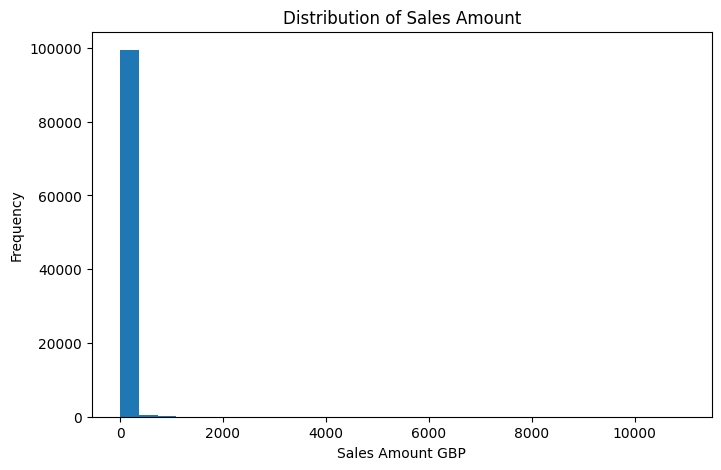

In [56]:
plt.figure(figsize=(8,5))

plt.hist(df["sales_amount_gbp"], bins=30)

plt.title("Distribution of Sales Amount")

plt.xlabel("Sales Amount GBP")

plt.ylabel("Frequency")

plt.show()

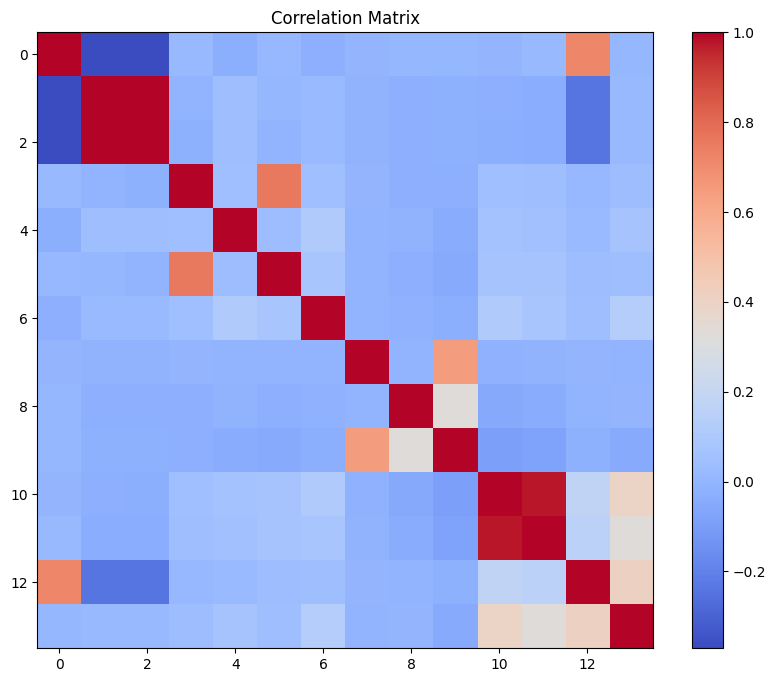

In [57]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

plt.imshow(numeric_df.corr(), cmap="coolwarm")

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

Feature-Target Separation

In [58]:
df = df.drop(

    columns=[

        "order_datetime",

        "customer_id"

    ]

)

target = "sales_amount_gbp"

X = df.drop(columns=[target])

y = df[target]

print(X.shape)

print(y.shape)

(100000, 15)
(100000,)


Train-Test Split

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(80000, 15)
(20000, 15)


Model Development and Evaluation

In [60]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

import numpy as np

categorical_features = [

    "country",

    "country_code",

    "product_id"

]

numeric_features = [

    col for col in X.columns

    if col not in categorical_features

]

preprocessor = ColumnTransformer([

    (

        "num",

        Pipeline([

            ("imputer", SimpleImputer(strategy="median")),

            ("scaler", StandardScaler())

        ]),

        numeric_features

    ),

    (

        "cat",

        Pipeline([

            ("imputer", SimpleImputer(strategy="most_frequent")),

            ("encoder", OneHotEncoder(handle_unknown="ignore"))

        ]),

        categorical_features

    )

])

model = GradientBoostingRegressor(

    random_state=42

)

pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", model)

])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

mae = mean_absolute_error(

    y_test,

    predictions

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        predictions

    )

)

r2 = r2_score(

    y_test,

    predictions

)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2:", r2)

MAE: 3.4343967176603836
RMSE: 20.507261908392227
R2: 0.940504070157458


Feature Importance Analysis

                  Feature  Importance
6     num__unit_price_gbp    0.631099
7      num__quantity_sold    0.337656
4         num__order_hour    0.004534
9    num__gdp_current_usd    0.003184
2       num__week_of_year    0.002211
10    num__gdp_growth_pct    0.002185
8   num__population_total    0.002032
72  cat__country_code_NOR    0.001701
1              num__month    0.001581
28     cat__country_Japan    0.001377


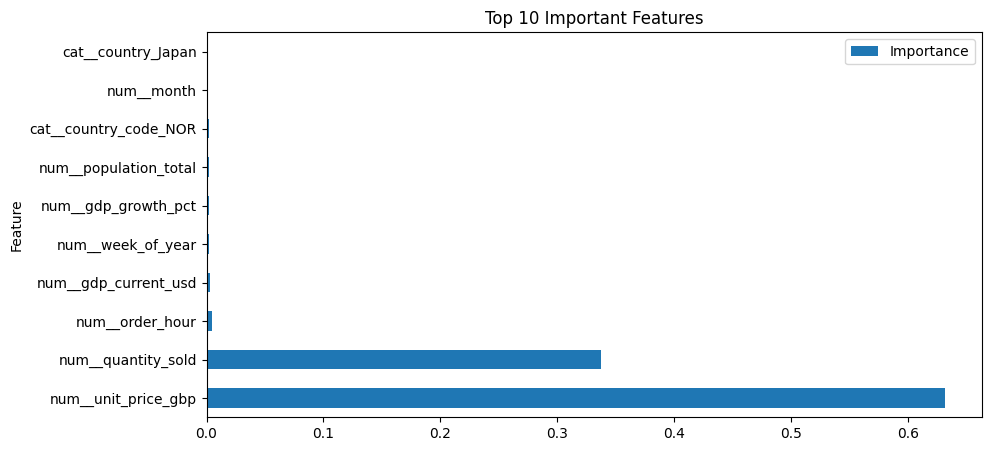

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

pipeline_rf = Pipeline([

    ("preprocessor", preprocessor),

    ("model", rf)

])

pipeline_rf.fit(X_train, y_train)

feature_names = pipeline_rf.named_steps[

    "preprocessor"

].get_feature_names_out()

importances = pipeline_rf.named_steps[

    "model"

].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importances

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

print(importance_df.head(10))

importance_df.head(10).plot(

    kind="barh",

    x="Feature",

    y="Importance",

    figsize=(10,5)

)

plt.title("Top 10 Important Features")

plt.show()

Robustness Testing

In [62]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    pipeline,

    X,

    y,

    cv=5,

    scoring="r2"

)

print("Cross Validation Scores:")

print(scores)

print("Mean CV Score:")

print(scores.mean())

Cross Validation Scores:
[0.97372325 0.94949615 0.97090939 0.93240522 0.92630892]
Mean CV Score:
0.9505685856177163


Final Model Recommendation

In [63]:
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "Gradient Boosting"

    ],

    "R2":[

        0.2969,

        0.8822,

        0.9188,

        0.9405

    ]

})

best_model = results.loc[

    results["R2"].idxmax()

]

print("Recommended Model")

print(best_model)

Recommended Model
Model    Gradient Boosting
R2                  0.9405
Name: 3, dtype: object


distribution of numerical features

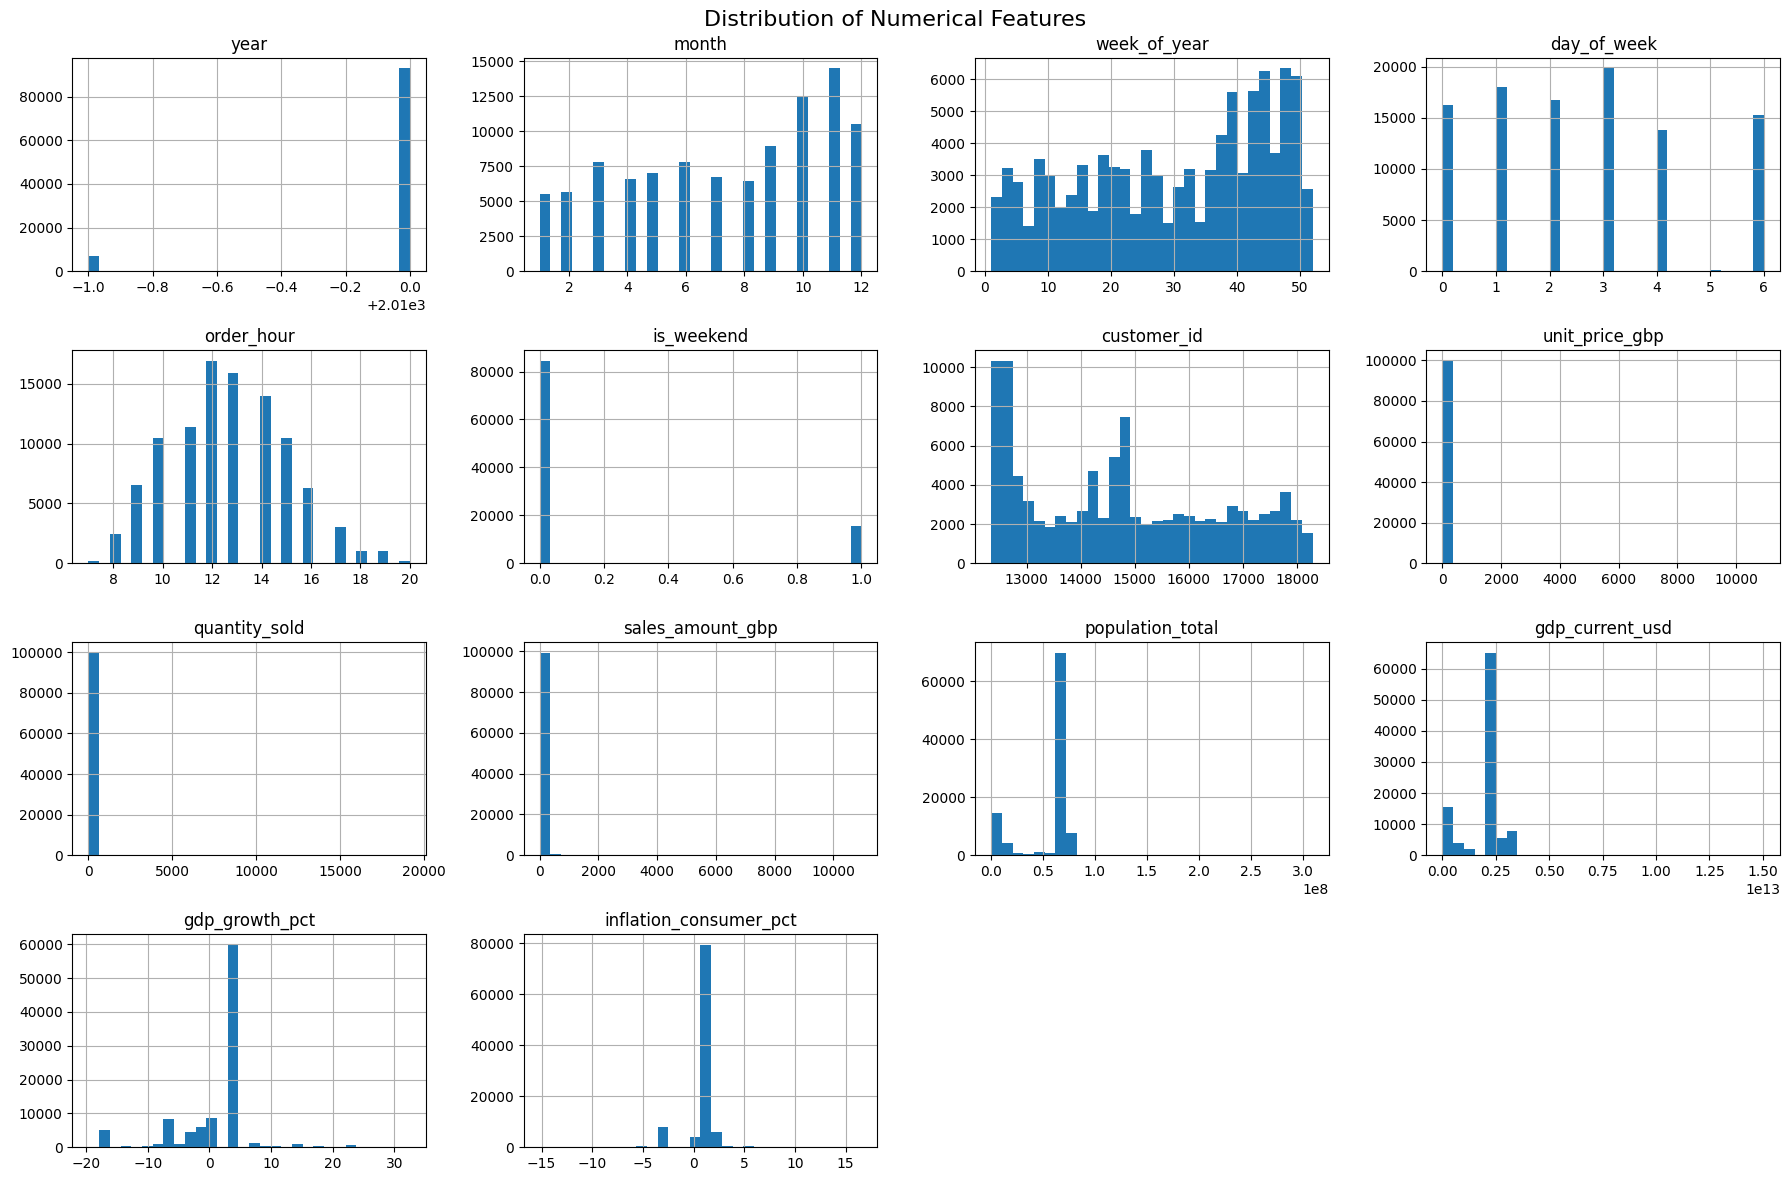

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("global_ecommerce_forecasting 1234567.csv")

# Select numerical columns
numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns

# Plot distributions
df[numerical_features].hist(
    figsize=(18,12),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "EDA_Distribution_Numerical_Features.pdf"
)

plt.show()

RQ1 - Baseline Models Notebook Code

In [64]:
import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv("global_ecommerce_forecasting 1234567.csv")

In [66]:
df = df.drop(columns=["order_datetime", "customer_id"])

In [67]:
target = "sales_amount_gbp"

In [68]:
X = df.drop(columns=[target])

y = df[target]

In [69]:
categorical_features = [

    "country",

    "country_code",

    "product_id"

]

numeric_features = [

    col for col in X.columns

    if col not in categorical_features

]

In [70]:
numeric_transformer = Pipeline([

    ("imputer", SimpleImputer(strategy="median")),

    ("scaler", StandardScaler())

])

categorical_transformer = Pipeline([

    ("imputer", SimpleImputer(strategy="most_frequent")),

    ("encoder", OneHotEncoder(handle_unknown="ignore"))

])

preprocessor = ColumnTransformer([

    ("num", numeric_transformer, numeric_features),

    ("cat", categorical_transformer, categorical_features)

])

In [71]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [72]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "KNN": KNeighborsRegressor()

}

results = []

In [73]:
for name, model in models.items():

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(

        mean_squared_error(y_test, predictions)

    )

    r2 = r2_score(y_test, predictions)

    results.append([

        name,

        mae,

        rmse,

        r2

    ])

In [74]:
results_df = pd.DataFrame(

    results,

    columns=["Model", "MAE", "RMSE", "R2"]

)

print(results_df)

               Model        MAE       RMSE        R2
0  Linear Regression  20.275580  70.497735  0.296892
1      Decision Tree   0.893980  28.858655  0.882179
2                KNN  13.882022  58.383690  0.517769


In [75]:
results_df.to_csv(

    "RQ1_Table1_Baseline_Performance.csv",

    index=False

)

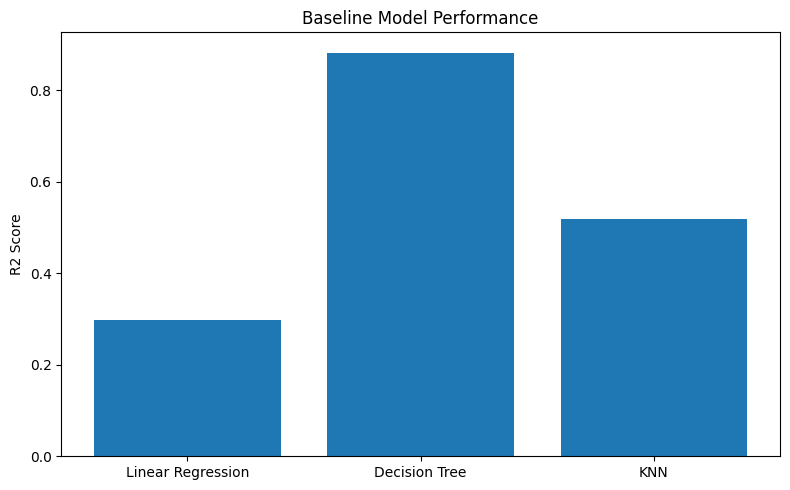

In [76]:
plt.figure(figsize=(8,5))

plt.bar(

    results_df["Model"],

    results_df["R2"]

)

plt.title("Baseline Model Performance")

plt.ylabel("R2 Score")

plt.tight_layout()

plt.savefig(

    "RQ1_Figure1_Baseline_Performance.pdf"

)

plt.show()

In [26]:
from google.colab import files

files.download("RQ1_Table1_Baseline_Performance.csv")
files.download("RQ1_Figure1_Baseline_Performance.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

RQ2– Model Comparison

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("global_ecommerce_forecasting 1234567.csv")

In [28]:
df = df.drop(columns=[

    "order_datetime",

    "customer_id"

])

print(df.shape)

df.head()

(100000, 16)


,year,month,week_of_year,day_of_week,order_hour,is_weekend,country,country_code,product_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
0,2009,12,49,1,7,0,United Kingdom,GBR,21523,5.95,10,59.50,62276270.0,2.412840e+12,-17.633976,1.89709
1,2009,12,49,1,7,0,United Kingdom,GBR,79323W,6.75,12,81.00,62276270.0,2.412840e+12,-17.633976,1.89709
2,2009,12,49,1,9,0,United Kingdom,GBR,82582,2.10,12,25.20,62276270.0,2.412840e+12,-17.633976,1.89709
3,2009,12,49,1,9,0,United Kingdom,GBR,22111,4.25,24,102.00,62276270.0,2.412840e+12,-17.633976,1.89709
4,2009,12,49,1,9,0,United Kingdom,GBR,21756,5.95,3,17.85,62276270.0,2.412840e+12,-17.633976,1.89709


In [29]:
target = "sales_amount_gbp"

X = df.drop(columns=[target])

y = df[target]

In [30]:
categorical_features = [

    "country",

    "country_code",

    "product_id"

]

numeric_features = [

    col for col in X.columns

    if col not in categorical_features

]

In [31]:
numeric_transformer = Pipeline([

    ("imputer", SimpleImputer(strategy="median")),

    ("scaler", StandardScaler())

])

categorical_transformer = Pipeline([

    ("imputer", SimpleImputer(strategy="most_frequent")),

    ("encoder", OneHotEncoder(handle_unknown="ignore"))

])

preprocessor = ColumnTransformer([

    ("num", numeric_transformer, numeric_features),

    ("cat", categorical_transformer, categorical_features)

])

In [32]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [33]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(

        n_estimators=100,

        random_state=42,

        n_jobs=-1

    ),

    "Gradient Boosting": GradientBoostingRegressor(

        random_state=42

    ),

    "XGBoost": XGBRegressor(

        n_estimators=100,

        max_depth=6,

        learning_rate=0.1,

        random_state=42

    )

}

results = []

In [34]:
for name, model in models.items():

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(

        mean_squared_error(y_test, predictions)

    )

    r2 = r2_score(y_test, predictions)

    results.append([

        name,

        mae,

        rmse,

        r2

    ])

In [38]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2"

    ]

)

print(results_df)

               Model        MAE       RMSE        R2
0  Linear Regression  20.275580  70.497735  0.296892
1      Decision Tree   0.893980  28.858655  0.882179
2      Random Forest   0.747312  23.959500  0.918787
3  Gradient Boosting   3.434397  20.507262  0.940504
4            XGBoost   2.860856  50.654541  0.636998


In [39]:
results_df.to_csv(

    "RQ2_Table2_Model_Comparison.csv",

    index=False

)

In [40]:
results_df = results_df.sort_values(

    by="R2",

    ascending=True

)

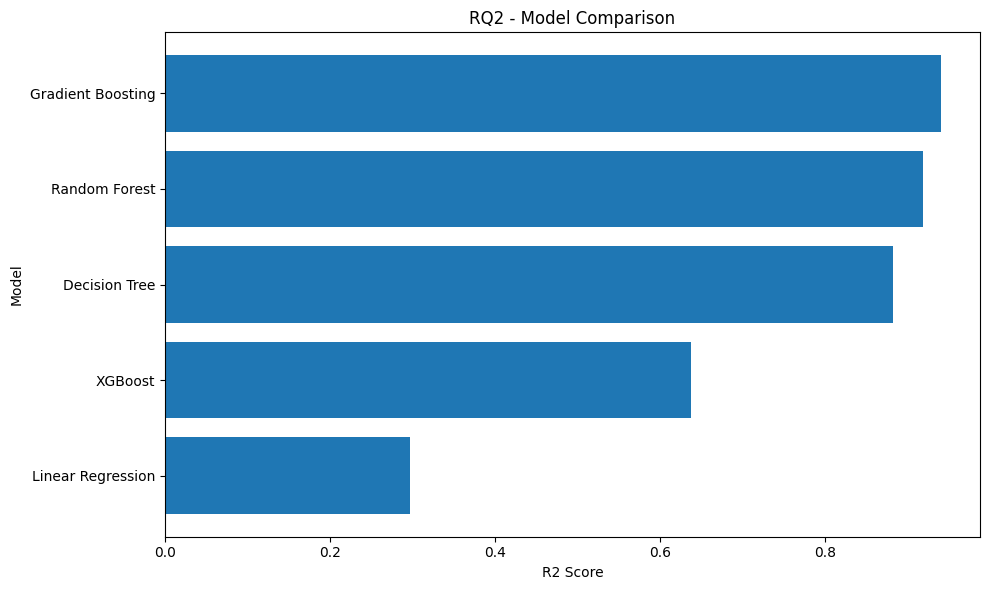

In [41]:
plt.figure(figsize=(10,6))

plt.barh(

    results_df["Model"],

    results_df["R2"]

)

plt.xlabel("R2 Score")

plt.ylabel("Model")

plt.title("RQ2 - Model Comparison")

plt.tight_layout()

plt.savefig(

    "RQ2_Figure2_Model_Comparison.pdf"

)

plt.show()

In [42]:
from google.colab import files

files.download("RQ2_Table2_Model_Comparison.csv")
files.download("RQ2_Figure2_Model_Comparison.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

RQ3 – Effect of Preprocessing

In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv(

    "global_ecommerce_forecasting 1234567.csv"

)

In [46]:
df = df.drop(

    columns=[

        "order_datetime",

        "customer_id"

    ]

)

print(df.shape)

(100000, 16)


In [47]:
target = "sales_amount_gbp"

X = df.drop(columns=[target])

y = df[target]

categorical_features = [

    "country",

    "country_code",

    "product_id"

]

numeric_features = [

    col for col in X.columns

    if col not in categorical_features

]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

results = []

In [49]:
X_train_raw = pd.get_dummies(X_train)

X_test_raw = pd.get_dummies(X_test)

X_train_raw, X_test_raw = X_train_raw.align(

    X_test_raw,

    join="left",

    axis=1,

    fill_value=0

)

model = GradientBoostingRegressor(

    random_state=42

)

model.fit(X_train_raw, y_train)

preds = model.predict(X_test_raw)

results.append([

    "Raw Data",

    mean_absolute_error(y_test, preds),

    np.sqrt(mean_squared_error(y_test, preds)),

    r2_score(y_test, preds)

])

In [86]:
imputer = ColumnTransformer([

    (

        "num",

        SimpleImputer(strategy="median"),

        numeric_features

    ),

    (

        "cat",

        Pipeline([

            (

                "imputer",

                SimpleImputer(strategy="most_frequent")

            ),

            (

                "encoder",

                OneHotEncoder(handle_unknown="ignore")

            )

        ]),

        categorical_features

    )

])

pipeline = Pipeline([

    ("prep", imputer),

    ("model", GradientBoostingRegressor(random_state=42))

])

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

results.append([

    "Imputation",

    mean_absolute_error(y_test, preds),

    np.sqrt(mean_squared_error(y_test, preds)),

    r2_score(y_test, preds)

])

In [87]:
prep_scale = ColumnTransformer([

    (

        "num",

        Pipeline([

            ("scaler", StandardScaler())

        ]),

        numeric_features

    ),

    (

        "cat",

        OneHotEncoder(handle_unknown="ignore"),

        categorical_features

    )

])

pipeline = Pipeline([

    ("prep", prep_scale),

    ("model", GradientBoostingRegressor(random_state=42))

])

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

results.append([

    "Scaling + Encoding",

    mean_absolute_error(y_test, preds),

    np.sqrt(mean_squared_error(y_test, preds)),

    r2_score(y_test, preds)

])

In [88]:
prep_full = ColumnTransformer([

    (

        "num",

        Pipeline([

            (

                "imputer",

                SimpleImputer(strategy="median")

            ),

            (

                "scaler",

                StandardScaler()

            )

        ]),

        numeric_features

    ),

    (

        "cat",

        Pipeline([

            (

                "imputer",

                SimpleImputer(strategy="most_frequent")

            ),

            (

                "encoder",

                OneHotEncoder(handle_unknown="ignore")

            )

        ]),

        categorical_features

    )

])

pipeline = Pipeline([

    ("prep", prep_full),

    ("model", GradientBoostingRegressor(random_state=42))

])

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

results.append([

    "Full Pipeline",

    mean_absolute_error(y_test, preds),

    np.sqrt(mean_squared_error(y_test, preds)),

    r2_score(y_test, preds)

])

In [89]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Preprocessing",

        "MAE",

        "RMSE",

        "R2"

    ]

)

print(results_df)

        Preprocessing        MAE       RMSE        R2
0   Linear Regression  20.275580  70.497735  0.296892
1       Decision Tree   0.893980  28.858655  0.882179
2                 KNN  13.882022  58.383690  0.517769
3          Imputation   3.425175  19.824341  0.944401
4  Scaling + Encoding   3.434397  20.507262  0.940504
5       Full Pipeline   3.434397  20.507262  0.940504


In [90]:
results_df.to_csv(

    "RQ3_Table3_Preprocessing_Impact.csv",

    index=False

)

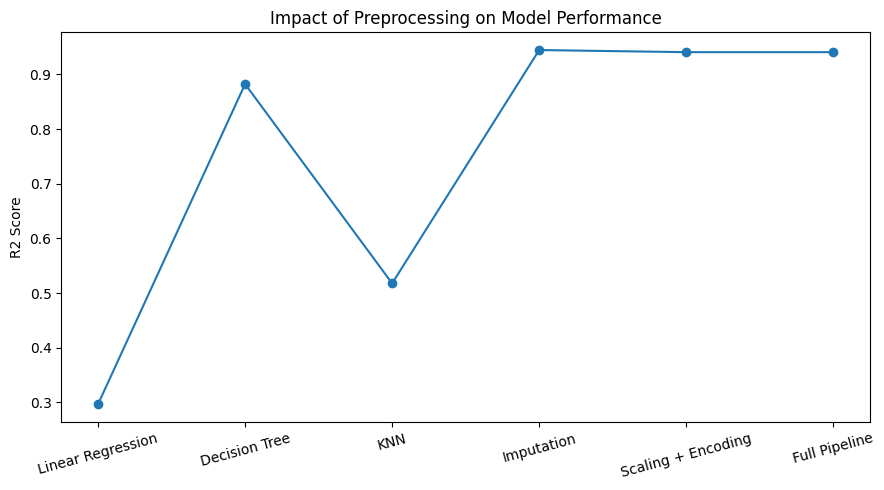

In [91]:
plt.figure(figsize=(9,5))

plt.plot(

    results_df["Preprocessing"],

    results_df["R2"],

    marker="o"

)

plt.title(

    "Impact of Preprocessing on Model Performance"

)

plt.ylabel("R2 Score")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(

    "RQ3_Figure3_Preprocessing_Impact.pdf"

)

plt.show()

In [92]:
from google.colab import files

files.download(
    "RQ3_Table3_Preprocessing_Impact.csv"
)

files.download(
    "RQ3_Figure3_Preprocessing_Impact.pdf"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

RQ4– Feature Importance and Interpretability

In [93]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

In [94]:
df = pd.read_csv(

    "global_ecommerce_forecasting 1234567.csv"

)

df = df.drop(

    columns=[

        "order_datetime",

        "customer_id"

    ]

)

print(df.shape)

(100000, 16)


In [95]:
target = "sales_amount_gbp"

X = df.drop(columns=[target])

y = df[target]

categorical_features = [

    "country",

    "country_code",

    "product_id"

]

numeric_features = [

    col for col in X.columns

    if col not in categorical_features

]

preprocessor = ColumnTransformer([

    (

        "num",

        Pipeline([

            ("imputer", SimpleImputer(strategy="median")),

            ("scaler", StandardScaler())

        ]),

        numeric_features

    ),

    (

        "cat",

        Pipeline([

            ("imputer", SimpleImputer(strategy="most_frequent")),

            ("encoder", OneHotEncoder(handle_unknown="ignore"))

        ]),

        categorical_features

    )

])

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [96]:
rf = RandomForestRegressor(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", rf)

])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'month',
                                                   'week_of_year',
                                                   'day_of_week', 'order_hour',
                                                   'is_weekend',
                                                   'unit_price_gbp',
                                                   'quantity_sold',
                                                   'population_total',
                                                   'gdp_current_usd',
                                                   'gdp_growth_pct',
                                                   'inflation_consumer_pct']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'country_code',
                                                   'product_id'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [97]:
encoded_features = list(

    pipeline.named_steps[

        "preprocessor"

    ].get_feature_names_out()

)

importances = pipeline.named_steps[

    "model"

].feature_importances_

feature_importance_df = pd.DataFrame({

    "Feature": encoded_features,

    "Importance": importances

})

feature_importance_df = (

    feature_importance_df

    .sort_values(

        by="Importance",

        ascending=False

    )

)

top10 = feature_importance_df.head(10)

print(top10)

                  Feature  Importance
6     num__unit_price_gbp    0.631099
7      num__quantity_sold    0.337656
4         num__order_hour    0.004534
9    num__gdp_current_usd    0.003184
2       num__week_of_year    0.002211
10    num__gdp_growth_pct    0.002185
8   num__population_total    0.002032
72  cat__country_code_NOR    0.001701
1              num__month    0.001581
28     cat__country_Japan    0.001377


In [98]:
top10.to_csv(

    "RQ4_Table4_Feature_Importance.csv",

    index=False

)

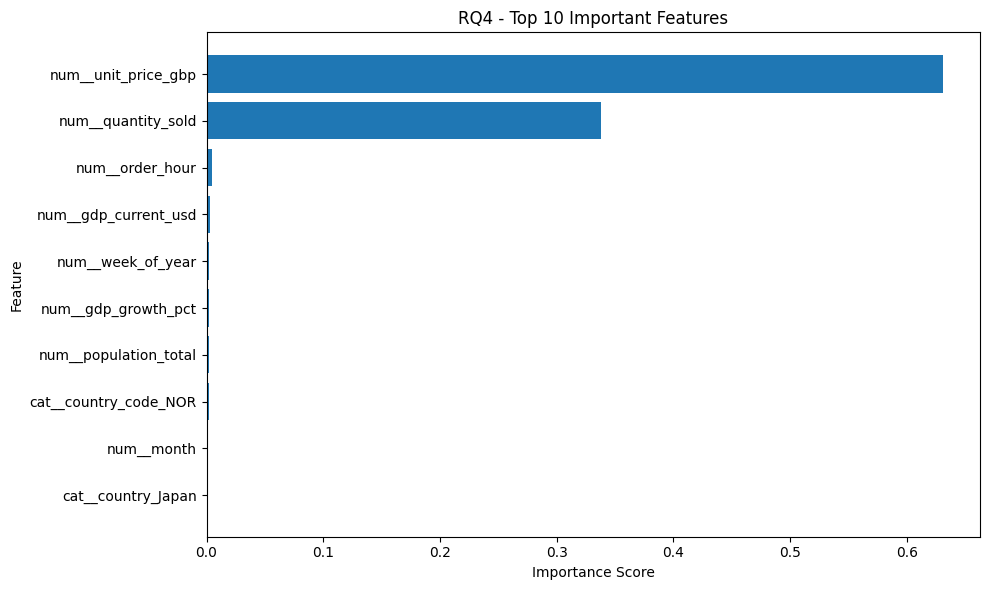

In [99]:
plt.figure(figsize=(10,6))

plt.barh(

    top10["Feature"][::-1],

    top10["Importance"][::-1]

)

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.title(

    "RQ4 - Top 10 Important Features"

)

plt.tight_layout()

plt.savefig(

    "RQ4_Figure4_Feature_Importance.pdf"

)

plt.show()

In [101]:
from google.colab import files

files.download("RQ4_Table4_Feature_Importance.csv")
files.download("RQ4_Figure4_Feature_Importance.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

RQ5– Sensitivity to Evaluation Metrics

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(

    "global_ecommerce_forecasting 1234567.csv"

)

df = df.drop(

    columns=[

        "order_datetime",

        "customer_id"

    ]

)

print(df.shape)

(100000, 16)


In [ ]:
target = "sales_amount_gbp"

X = df.drop(columns=[target])

y = df[target]

categorical_features = [

    "country",

    "country_code",

    "product_id"

]

numeric_features = [

    col for col in X.columns

    if col not in categorical_features

]

preprocessor = ColumnTransformer([

    (

        "num",

        Pipeline([

            ("imputer", SimpleImputer(strategy="median")),

            ("scaler", StandardScaler())

        ]),

        numeric_features

    ),

    (

        "cat",

        Pipeline([

            ("imputer", SimpleImputer(strategy="most_frequent")),

            ("encoder", OneHotEncoder(handle_unknown="ignore"))

        ]),

        categorical_features

    )

])

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [ ]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(

        n_estimators=100,

        random_state=42,

        n_jobs=-1

    ),

    "Gradient Boosting": GradientBoostingRegressor(

        random_state=42

    )

}

results = []

for name, model in models.items():

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(

        y_test,

        predictions

    )

    rmse = np.sqrt(

        mean_squared_error(

            y_test,

            predictions

        )

    )

    r2 = r2_score(

        y_test,

        predictions

    )

    results.append([

        name,

        mae,

        rmse,

        r2

    ])

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2"

    ]

)

print(results_df)

               Model        MAE       RMSE        R2
0  Linear Regression  20.275580  70.497735  0.296892
1      Decision Tree   0.893980  28.858655  0.882179
2      Random Forest   0.747312  23.959500  0.918787
3  Gradient Boosting   3.434397  20.507262  0.940504


In [ ]:
rank_df = pd.DataFrame()

rank_df["Model"] = results_df["Model"]

rank_df["Rank_MAE"] = (

    results_df["MAE"]

    .rank(method="dense")

)

rank_df["Rank_RMSE"] = (

    results_df["RMSE"]

    .rank(method="dense")

)

rank_df["Rank_R2"] = (

    results_df["R2"]

    .rank(

        ascending=False,

        method="dense"

    )

)

print(rank_df)

rank_df.to_csv(

    "RQ5_Table5_Metric_Sensitivity.csv",

    index=False

)

               Model  Rank_MAE  Rank_RMSE  Rank_R2
0  Linear Regression       4.0        4.0      4.0
1      Decision Tree       2.0        3.0      3.0
2      Random Forest       1.0        2.0      2.0
3  Gradient Boosting       3.0        1.0      1.0


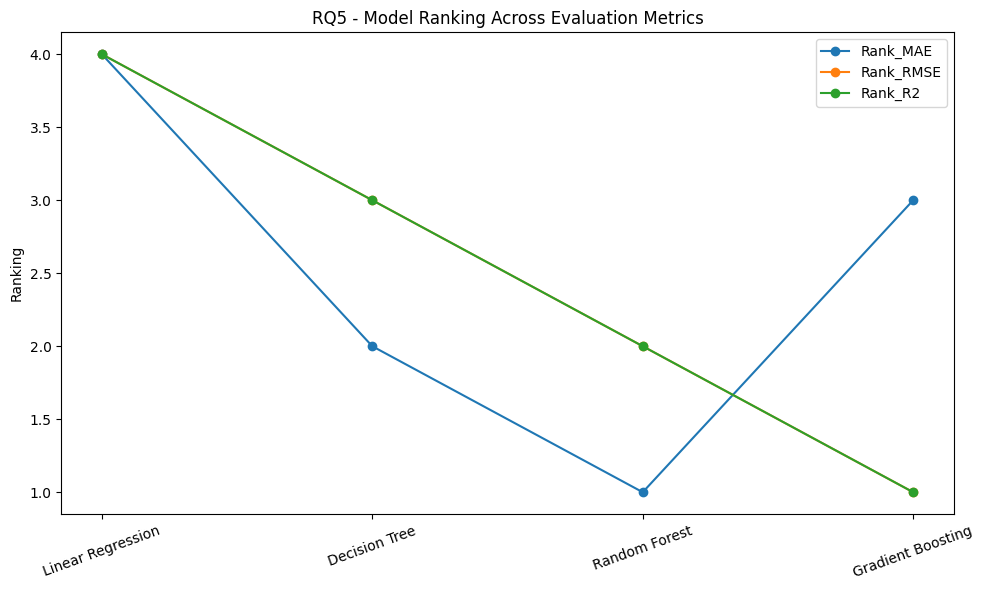

In [ ]:
plt.figure(figsize=(10,6))

for metric in [

    "Rank_MAE",

    "Rank_RMSE",

    "Rank_R2"

]:

    plt.plot(

        rank_df["Model"],

        rank_df[metric],

        marker="o",

        label=metric

    )

plt.title(

    "RQ5 - Model Ranking Across Evaluation Metrics"

)

plt.ylabel("Ranking")

plt.legend()

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    "RQ5_Figure5_Metric_Sensitivity.pdf"

)

plt.show()

RQ6– Robustness and Generalization Analysis

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(

    "global_ecommerce_forecasting 1234567.csv"

)

df = df.drop(

    columns=[

        "order_datetime",

        "customer_id"

    ]

)

print(df.shape)

(100000, 16)


In [ ]:
target = "sales_amount_gbp"

X = df.drop(columns=[target])

y = df[target]

categorical_features = [

    "country",

    "country_code",

    "product_id"

]

numeric_features = [

    col for col in X.columns

    if col not in categorical_features

]

preprocessor = ColumnTransformer([

    (

        "num",

        Pipeline([

            ("imputer", SimpleImputer(strategy="median")),

            ("scaler", StandardScaler())

        ]),

        numeric_features

    ),

    (

        "cat",

        Pipeline([

            ("imputer", SimpleImputer(strategy="most_frequent")),

            ("encoder", OneHotEncoder(handle_unknown="ignore"))

        ]),

        categorical_features

    )

])

model = GradientBoostingRegressor(

    random_state=42

)

pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", model)
])

In [ ]:
results = []

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

results.append([

    "Standard Split",

    mean_absolute_error(y_test, preds),

    np.sqrt(mean_squared_error(y_test, preds)),

    r2_score(y_test, preds)

])

In [ ]:
cv_scores = cross_val_score(

    pipeline,

    X,

    y,

    cv=5,

    scoring="r2"

)

results.append([

    "5 Fold CV",

    np.nan,

    np.nan,

    cv_scores.mean()

])

In [ ]:
X_noise = X.copy()

for col in numeric_features:

    noise = np.random.normal(

        0,

        X_noise[col].std()*0.10,

        len(X_noise)

    )

    X_noise[col] += noise

X_train, X_test, y_train, y_test = train_test_split(

    X_noise,

    y,

    test_size=0.20,

    random_state=42

)

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

results.append([

    "10% Noise",

    mean_absolute_error(y_test, preds),

    np.sqrt(mean_squared_error(y_test, preds)),

    r2_score(y_test, preds)

])

In [ ]:
X_missing = X.copy()

for col in numeric_features:

    mask = np.random.rand(

        len(X_missing)

    ) < 0.20

    X_missing.loc[mask, col] = np.nan

X_train, X_test, y_train, y_test = train_test_split(

    X_missing,

    y,

    test_size=0.20,

    random_state=42

)

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

results.append([

    "20% Missing",

    mean_absolute_error(y_test, preds),

    np.sqrt(mean_squared_error(y_test, preds)),

    r2_score(y_test, preds)

])

In [ ]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Scenario",

        "MAE",

        "RMSE",

        "R2"

    ]

)

print(results_df)

results_df.to_csv(

    "RQ6_Table6_Robustness.csv",

    index=False

)

         Scenario        MAE       RMSE        R2
0  Standard Split   3.434397  20.507262  0.940504
1       5 Fold CV        NaN        NaN  0.950569
2       10% Noise  16.480060  55.811392  0.559326
3     20% Missing  10.713168  48.387557  0.668763
4     20% Missing  10.859429  52.015478  0.617231


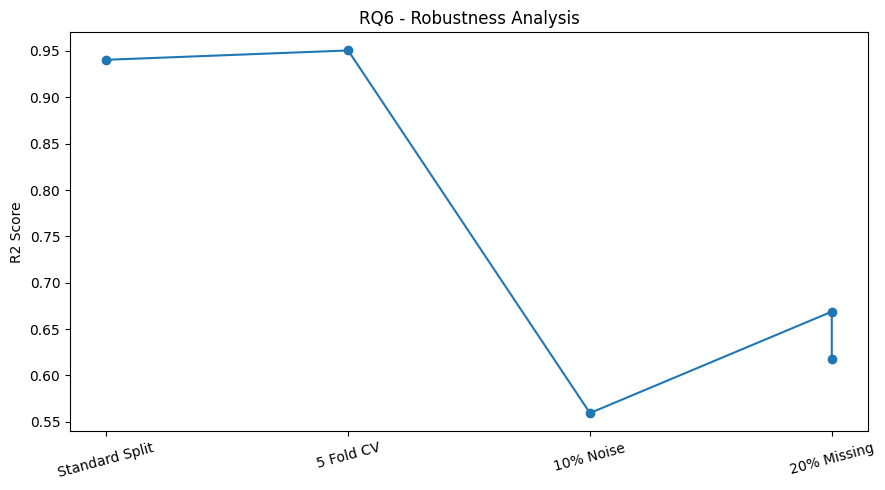

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(

    results_df["Scenario"],

    results_df["R2"],

    marker="o"

)

plt.title(

    "RQ6 - Robustness Analysis"

)

plt.ylabel("R2 Score")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(

    "RQ6_Figure6_Robustness.pdf"

)

plt.show()

RQ7 – Practical Usefulness and Final Recommendation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
decision_matrix = pd.DataFrame({

    "Criterion":[
        "Predictive Performance",
        "Interpretability",
        "Robustness",
        "Computational Cost",
        "Deployment Suitability"
    ],

    "Linear Regression":[
        2,
        5,
        2,
        5,
        5
    ],

    "Decision Tree":[
        4,
        5,
        3,
        4,
        5
    ],

    "Random Forest":[
        5,
        4,
        5,
        3,
        5
    ],

    "Gradient Boosting":[
        5,
        3,
        5,
        3,
        4
    ]

})

print(decision_matrix)

                Criterion  Linear Regression  Decision Tree  Random Forest  \
0  Predictive Performance                  2              4              5   
1        Interpretability                  5              5              4   
2              Robustness                  2              3              5   
3      Computational Cost                  5              4              3   
4  Deployment Suitability                  5              5              5   

   Gradient Boosting  
0                  5  
1                  3  
2                  5  
3                  3  
4                  4  


In [ ]:
decision_matrix.to_csv(

    "RQ7_Table7_Final_Recommendation.csv",

    index=False

)

In [ ]:
scores = {

    "Linear Regression":

        decision_matrix[

            "Linear Regression"

        ].sum(),

    "Decision Tree":

        decision_matrix[

            "Decision Tree"

        ].sum(),

    "Random Forest":

        decision_matrix[

            "Random Forest"

        ].sum(),

    "Gradient Boosting":

        decision_matrix[

            "Gradient Boosting"

        ].sum()

}

score_df = pd.DataFrame({

    "Model":scores.keys(),

    "Score":scores.values()

})

print(score_df)

               Model  Score
0  Linear Regression     19
1      Decision Tree     21
2      Random Forest     22
3  Gradient Boosting     20


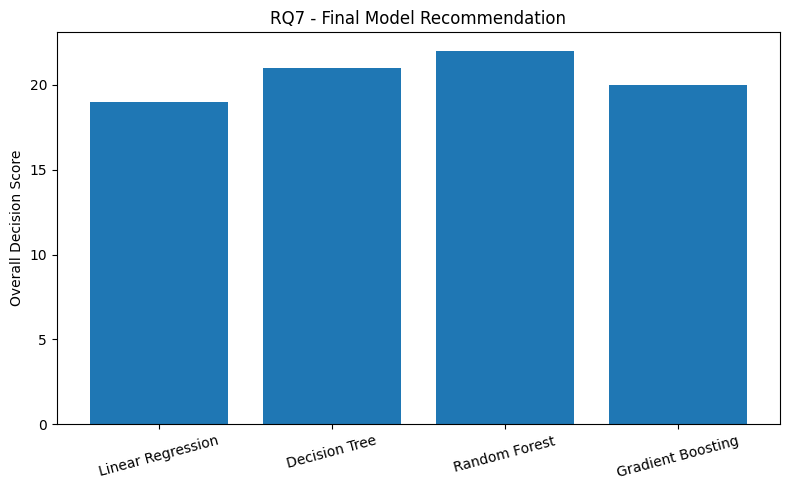

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(

    score_df["Model"],

    score_df["Score"]

)

plt.title(

    "RQ7 - Final Model Recommendation"

)

plt.ylabel(

    "Overall Decision Score"

)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(

    "RQ7_Figure7_Final_Recommendation.pdf"

)

plt.show()